In [1]:
from pathlib import Path
import pandas as pd

In [2]:
import rpy2

In [3]:
%load_ext rpy2.ipython

In [4]:
%%R
install.packages("funkyheatmap")
install.packages("svglite")

--- Please select a CRAN mirror for use in this session ---
Secure CRAN mirrors 

 1: 0-Cloud [https]                   2: Australia (Canberra) [https]   
 3: Australia (Melbourne 1) [https]   4: Australia (Melbourne 2) [https]
 5: Austria (Wien) [https]            6: Belgium (Brussels) [https]     
 7: Brazil (PR) [https]               8: Brazil (SP 1) [https]          
 9: Brazil (SP 2) [https]            10: Bulgaria [https]               
11: Canada (MB) [https]              12: Canada (ON 1) [https]          
13: Canada (ON 2) [https]            14: Chile (Santiago) [https]       
15: China (Beijing 1) [https]        16: China (Beijing 2) [https]      
17: China (Beijing 3) [https]        18: China (Hefei) [https]          
19: China (Hong Kong) [https]        20: China (Jinan) [https]          
21: China (Lanzhou) [https]          22: China (Nanjing) [https]        
23: China (Shanghai 2) [https]       24: China (Shenzhen) [https]       
25: China (Wuhan) [https]            26: C

Selection:  37


* installing *source* package ‘funkyheatmap’ ...
** package ‘funkyheatmap’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** data
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (funkyheatmap)
* installing *source* package ‘svglite’ ...
** package ‘svglite’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C++ compiler: ‘x86_64-conda-linux-gnu-c++ (conda-forge gcc 14.2.0-2) 14.2.0’


x86_64-conda-linux-gnu-c++ -std=gnu++17 -I"/home/ubuntu/miniforge3/lib/R/include" -DNDEBUG  -I'/home/ubuntu/miniforge3/lib/R/library/cpp11/include' -I'/home/ubuntu/miniforge3/lib/R/library/systemfonts/include' -I'/home/ubuntu/miniforge3/lib/R/library/textshaping/include' -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/ubuntu/miniforge3/include -I/home/ubuntu/miniforge3/include -Wl,-rpath-link,/home/ubuntu/miniforge3/lib    -fpic  -fvisibility-inlines-hidden  -fmessage-length=0 -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/ubuntu/miniforge3/include -fdebug-prefix-map=/home/conda/feedstock_root/build_artifacts/r-base-split_1746101612493/work=/usr/local/src/conda/r-base-4.4.3 -fdebug-prefix-map=/home/ubuntu/miniforge3=/usr/local/src/conda-prefix   -c SvgStream.cpp -o SvgStream.o
x86_64-conda-linux-gnu-c++ -std=gnu++17 -I"/home/ubuntu/miniforge3/lib/R/include" -DNDEBUG  -I'/home/ubuntu/miniforge3/lib/R/lib

installing to /home/ubuntu/miniforge3/lib/R/library/00LOCK-svglite/00new/svglite/libs
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (svglite)


trying URL 'https://mirror.dogado.de/cran/src/contrib/funkyheatmap_0.5.2.tar.gz'
Content type 'application/octet-stream' length 1745259 bytes (1.7 MB)
downloaded 1.7 MB


The downloaded source packages are in
	‘/tmp/RtmpGmGQ5r/downloaded_packages’
Updating HTML index of packages in '.Library'
Making 'packages.html' ... done
trying URL 'https://mirror.dogado.de/cran/src/contrib/svglite_2.2.2.tar.gz'
Content type 'application/octet-stream' length 125651 bytes (122 KB)
downloaded 122 KB


The downloaded source packages are in
	‘/tmp/RtmpGmGQ5r/downloaded_packages’
Updating HTML index of packages in '.Library'
Making 'packages.html' ... done


In [5]:
main_dir = Path.cwd().parents[0] / 'data'
main_dir

PosixPath('/dss/dsshome1/0C/ra98gaq/Git/branch-metrics/cellseg-benchmark/data')

In [6]:
import sys
sys.path.insert(0, '/dss/dsshome1/0C/ra98gaq/Git/branch-metrics/cellseg-benchmark')

## load + format metric csvs

In [7]:
output_dir = main_dir / "metrics" / "aging"
output_folders = ["general_stats", "assigned_transcripts", "cell_type_metrics", "marker_gene_metrics"]

In [8]:
plots_dir_r = str(output_dir / "plots")
Path(plots_dir_r).mkdir(parents=True, exist_ok=True)

In [9]:
dfs = {}
for name in output_folders:
    p = output_dir / name
    if not p.exists():
        raise FileNotFoundError(f"{name} not found in {output_dir}")
    for csv in p.glob("*.csv"):
        if "vascular" not in csv.name:
            dfs[csv.stem] = pd.read_csv(csv, index_col=0)

In [10]:
dfs.keys()

dict_keys(['general_stats', 'assigned_transcript_counts', 'clustering_score_adata_integrated_leiden', 'cell_type_distribution_adata_integrated_cell_type_revised', 'negative_marker_purity_all', 'MECR_score_all', 'marker_f1_score_cell_type_revised_2', 'marker_f1_score_cell_type_revised', 'MECR_score_all_2'])

which data to extract how:
- general_stats
  - use metrics (one per col): ["volume_final", "elongation", "intensities_PolyT", "intensities_DAPI", "Ovrlpy_stats_mean_integrity"]
  - use "cell_type_revised" == "all" only
  - available per sample ("sample" col), compute mean across samples as final value per method (note: ignore sample == "all" values if available)
- assigned_transcript_counts
  - table is per gene only; sum up assigned counts across all genes (use code previously provided from plotting function - already implemented below).
  - Use "pct_assigned_qced"
  - take values from each sample ("sample" col), then compute mean across samples as final value per method (note: ignore sample == "all" values if available)
- clustering_score_adata_integrated_leiden
  - use metric (col): ["silhouette_score"]
  - take values from each sample ("sample" col), then compute mean across samples as final value per method (note: ignore sample == "all" values if available)
- cell_type_distribution_adata_integrated_cell_type_revised
  - col 'Undefined' only, which contains percentage of undefined cells
  - take values from each sample ("sample" col), then compute mean across samples as final value per method (note: ignore sample == "all" values if available)
- negative_marker_purity_all
  - col: "negative_marker_purity"
  - already in right format: available only across all samples and cell types
- MECR_score_all
  - given as value (col "MECR") per gene pair (in cols ["gene1", "gene2"]); use mean MECR from all pairs of each method (col "method")
  - compute this within each sample ("sample" col) first, then compute mean across samples as final value per method (note: ignore sample == "all" values if available)
- marker_f1_score_cell_type_revised
  - compute mean of metrics value (col "f1_score") per cell type (col "cell_type") first, then mean across all cell types
  - compute all this within each sample ("sample" col) first, then compute mean across samples as final value per method (note: ignore sample == "all" values if available)

In [11]:
dfs["marker_f1_score_cell_type_revised"]#["cell_type"].value_counts()

,method,sample,cell_type,marker_gene,f1_score,precision,recall,tp,fp,fn
0,Proseg_3D_Cellpose_1_nuclei_model,aging_s1_r0,BAMs,Mrc1,0.580645,0.523256,0.652174,90,82,48
1,Proseg_3D_Cellpose_1_nuclei_model,aging_s1_r0,BAMs,Pf4,0.040268,0.272727,0.021739,3,8,135
2,Proseg_3D_Cellpose_1_nuclei_model,aging_s1_r0,BAMs,Cd163,0.517241,0.638298,0.434783,60,34,78
3,Proseg_3D_Cellpose_1_nuclei_model,aging_s1_r0,BAMs,Ms4a7,0.092715,0.538462,0.050725,7,6,131
4,Proseg_3D_Cellpose_1_nuclei_model,aging_s1_r0,BAMs,Cybb,0.072917,0.129630,0.050725,7,47,131
...,...,...,...,...,...,...,...,...,...,...
34610,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,aging_s12_r0,VLMCs,Aldh1a2,0.329142,0.228322,0.589404,445,1504,310
34611,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,aging_s12_r0,VLMCs,Dcn,0.297240,0.248007,0.370861,280,849,475
34612,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,aging_s12_r0,VLMCs,Col1a1,0.230026,0.341146,0.173510,131,253,624
34613,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,aging_s12_r0,VLMCs,Osr1,0.114986,0.199346,0.080795,61,245,694


## plot heatmap

In [13]:
import cellseg_benchmark._constants as _constants

def norm_fixed(s, lo, hi, invert=False):
    n = ((s - lo) / (hi - lo)).clip(0, 1)
    return 1 - n if invert else n

def norm01(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0 + 0.5

def build_benchmark_table(dfs):
    # --- collect per-method metrics ---
    gs_cols = ["volume_final", "elongation", "intensities_PolyT",
               "intensities_DAPI", "Ovrlpy_stats_mean_integrity", "n_cells"]
    gs = dfs["general_stats"].query("cell_type_revised == 'all' and sample != 'all'")
    parts = [gs.groupby("method")[gs_cols].mean()]

    at = (dfs["assigned_transcript_counts"]
          .query("sample != 'all'")
          .groupby(["sample", "method"], as_index=False)
          [["assigned_count_qced", "total_count"]].sum())
    at["pct_assigned_qced"] = at["assigned_count_qced"] / at["total_count"]
    parts.append(at.groupby("method")[["pct_assigned_qced"]].mean())

    parts.append(
        dfs["clustering_score_adata_integrated_leiden"]
        .query("sample != 'all'")
        .groupby("method")[["silhouette_score"]].mean()
    )

    parts.append(
        dfs["cell_type_distribution_adata_integrated_cell_type_revised"]
        .query("sample != 'all'")
        .groupby("method")[["Undefined"]].mean()
    )

    parts.append(
        dfs["negative_marker_purity_all"]
        .set_index("method")[["negative_marker_purity"]]
    )

    mecr = dfs["MECR_score_all"].query("sample != 'all'")
    parts.append(
        mecr.groupby(["sample", "method"])["MECR"].mean()
        .groupby("method").mean()
        .to_frame()
    )

    mf1 = dfs["marker_f1_score_cell_type_revised"].query("sample != 'all'")
    parts.append(
        mf1.groupby(["sample", "method", "cell_type"])["f1_score"].mean()
        .groupby(["sample", "method"]).mean()
        .groupby("method").mean()
        .rename("marker_f1_score")
        .to_frame()
    )
    
    raw = df = pd.concat(parts, axis=1)
    
    # --- score with fixed theoretical bounds ---
    BOUNDS = {
        "silhouette_score":            (-1.0, 1.0, False),
        "Undefined":                   ( 0.0, 1.0, True),
        "negative_marker_purity":      ( 0.0, 1.0, False),
        "MECR":                        ( 0.0, 1.0, True),
        "Ovrlpy_stats_mean_integrity": ( 0.0, 1.0, False),
        "marker_f1_score":             ( 0.0, 1.0, False),
    }
    descriptive = ["volume_final", "elongation", "intensities_PolyT",
                   "intensities_DAPI", "n_cells", "pct_assigned_qced"]

    df["n_cells_raw"] = df["n_cells"].astype(int)

    # 1. total_score: comparable across datasets
    df["total_score"] = pd.DataFrame(
        {c: norm_fixed(df[c], lo, hi, inv) for c, (lo, hi, inv) in BOUNDS.items()},
        index=df.index
    ).mean(axis=1)
    df = df.sort_values("total_score", ascending=False)

    # 2. display: min-max per column for heatmap contrast
    for c, (lo, hi, inv) in BOUNDS.items():
        df[c] = norm01(norm_fixed(df[c], lo, hi, inv))
    for c in descriptive:
        df[c] = norm01(df[c])

    # --- format for plotting ---
    df = df.reset_index().rename(columns={"method": "id"})
    for old, new in _constants.clean_method_names.items():
        df["id"] = df["id"].str.replace(old, new, regex=False)
    df["total_score_label"] = df["total_score"].apply(lambda x: f" {x:.2f}")
    df["n_cells_label"] = df["n_cells_raw"].apply(lambda x: f"{x/1000:.1f}k")
    return df, raw

df_funky, raw = build_benchmark_table(dfs)

In [19]:
df_funky#.head()

,id,volume_final,elongation,intensities_PolyT,intensities_DAPI,Ovrlpy_stats_mean_integrity,n_cells,pct_assigned_qced,silhouette_score,Undefined,negative_marker_purity,MECR,marker_f1_score,n_cells_raw,total_score,total_score_label,n_cells_label
0,Cellpose_1n,0.198426,2.518171e-01,1.000000,1.000000,0.180761,0.011975,0.363143,1.000000,0.970834,0.726410,0.153905,0.761343,44670,0.749839,0.75,44.7k
1,Proseg_3D_CP1n,0.253238,9.547624e-01,0.625243,0.585093,0.370579,0.011733,0.512088,0.966712,0.972185,0.666788,0.000000,0.678804,44530,0.745064,0.75,44.5k
2,Cellpose_1n_2D_VPT,0.115099,2.904832e-01,NaN,NaN,0.030604,0.024371,0.282303,0.867676,1.000000,0.110635,0.349817,0.911192,51895,0.732879,0.73,51.9k
3,Baysor_CP2P_0.2,0.189585,3.264947e-01,0.159485,0.144271,0.306329,0.189947,0.952122,0.432118,0.366514,0.881358,0.472618,0.416510,148398,0.705639,0.71,148.4k
4,Baysor_CP1T_0.8,0.238900,3.576649e-01,0.068497,0.065471,0.422580,0.129428,0.859128,0.264125,0.382471,0.850429,0.270711,0.321789,113125,0.700037,0.70,113.1k
5,Cellpose_1P,0.281323,2.841056e-01,0.721161,0.707121,0.268028,0.014536,0.454525,0.756932,0.918185,0.719515,NaN,0.626828,46164,0.699669,0.70,46.2k
6,Baysor_CP2T_0.8,0.253531,3.502235e-01,0.022158,0.034093,0.405130,0.121189,0.876825,0.423299,0.334931,0.844818,0.244687,0.283689,108324,0.697400,0.70,108.3k
7,Proseg_3D_CP1P,0.329409,1.000000e+00,0.510702,0.477733,0.419730,0.013979,0.560236,0.705288,0.921981,0.667294,NaN,0.587009,45838,0.696873,0.70,45.8k
8,Cellpose_1n_3D_VPT,0.064334,6.053092e-01,NaN,NaN,0.029037,0.022482,0.135281,0.831945,0.976750,0.265140,NaN,1.000000,50794,0.695499,0.70,50.8k
9,Cellpose_1P_3D_VPT,0.023375,7.940131e-01,NaN,NaN,0.040857,0.017043,0.000000,0.718717,0.881590,0.480069,NaN,0.953528,47625,0.694607,0.69,47.6k


In [15]:
# min/max before normalization
raw[raw.columns].agg(["min", "max", "mean", "median"]).round(2).T

,min,max,mean,median
volume_final,262.50,6562.48,1679.32,1672.46
elongation,0.00,0.55,0.24,0.18
intensities_PolyT,4337.18,5981.73,4752.85,4610.37
intensities_DAPI,5823.99,11534.21,7201.98,6783.96
Ovrlpy_stats_mean_integrity,0.80,0.84,0.82,0.82
n_cells,37691.80,620518.27,111757.54,77430.97
pct_assigned_qced,0.17,0.95,0.70,0.69
silhouette_score,0.06,0.20,0.13,0.13
Undefined,0.04,0.41,0.18,0.20
negative_marker_purity,0.78,0.99,0.92,0.95


In [16]:
%%R
plot_benchmark_heatmap <- function(df_funky, plots_dir_r) {
  library(funkyheatmap)
  library(dplyr)
  library(tibble)
  library(ggplot2)
  library(RColorBrewer)

  df_funky$sep1 <- ""

  col_spec <- tribble(
    ~id,                          ~group,        ~geom,       ~palette,       ~name,           ~opts,
    "id",                         "",            "text",      NA,             "",              list(width = 8, hjust = 0),
    "total_score",                "overall",     "bar",       "agg",          "Total",         list(width = 2),
    "total_score_label",          "overall",     "text",      NA,             "",              list(overlay = TRUE, size = 2.5, hjust = 0),
    "silhouette_score",           "clustering",  "funkyrect", "purples",      "Silhouette",    list(),
    "Undefined",                  "clustering",  "funkyrect", "purples",      "% undefined",   list(),
    "negative_marker_purity",     "marker",      "funkyrect", "reds",         "NMP",           list(),
    "MECR",                       "marker",      "funkyrect", "reds",         "MECR",          list(),
    "marker_f1_score",            "marker",      "funkyrect",  "reds",        "Marker F1",     list(),
    "Ovrlpy_stats_mean_integrity","doublets",    "funkyrect", "yellows",      "Z integrity",   list(),
    "sep1",                       "",            "text",      NA,             "",              list(width = 0.75),
    "volume_final",               "seg",         "funkyrect", "greens",       "Volume",        list(),
    "elongation",                 "seg",         "funkyrect", "greens",       "Elongation",    list(),
    "intensities_PolyT",          "seg",         "funkyrect", "greens",       "PolyT",         list(),
    "intensities_DAPI",           "seg",         "funkyrect", "greens",       "DAPI",          list(),
    "n_cells",                    "seg",         "rect",      "greens_dark",  "# cells",       list(),
    "n_cells_label",              "seg",         "text",      NA,             "",              list(overlay = TRUE, size = 2, colour = "black"),
    "pct_assigned_qced",          "transcripts", "funkyrect", "blues",        "% assigned",    list(),
  )

  column_info <- col_spec %>%
    rowwise() %>%
    mutate(options = list(opts)) %>%
    ungroup() %>%
    select(-opts) %>%
    mutate(legend = FALSE)

  column_groups <- tribble(
    ~group,        ~level1,       ~palette,
    "overall",     "Overall",     "agg",
    "clustering",  "Clustering",  "purples",
    "marker",      "Marker",      "reds",
    "doublets",    "VSI",         "yellows",
    "seg",         "General",     "greens",
    "transcripts", "Transcripts", "blues"
  )

  palettes <- list(
    agg         = brewer.pal(9, "YlOrBr"),
    greens      = brewer.pal(9, "Greens"),
    greens_dark = brewer.pal(9, "Greens")[3:7],
    blues       = brewer.pal(9, "Blues"),
    purples     = brewer.pal(9, "Purples"),
    reds        = brewer.pal(9, "Reds"),
    yellows     = brewer.pal(9, "YlOrBr")
  )

  legends <- list(
    list(title = "Score",   palette = "agg",    geom = "bar",       labels = c("0", "", "0.5", "", "1"), size = c(0, 0.25, 0.5, 0.75, 1),     color = brewer.pal(9, "YlOrBr")[c(1, 3, 5, 7, 9)]),
    list(title = "Metrics", palette = "greens", geom = "funkyrect", labels = c("0", "", "0.5", "", "1"), size = c(0.1, 0.3, 0.5, 0.75, 1.0), color = brewer.pal(9, "Greys")[c(1, 3, 5, 7, 9)]),
    list(palette = "purples",     enabled = FALSE),
    list(palette = "reds",        enabled = FALSE),
    list(palette = "yellows",     enabled = FALSE),
    list(palette = "blues",       enabled = FALSE),
    list(palette = "greens_dark", enabled = FALSE)
  )

  g <- funky_heatmap(
    df_funky,
    column_info   = column_info,
    column_groups = column_groups,
    palettes      = palettes,
    legends       = legends,
    scale_column  = FALSE,
    position_args = position_arguments(
      expand_xmax = 9, expand_ymin = 0.5,
      expand_ymax = 4, col_annot_offset = 3, col_annot_angle = 45
    )
  )

  ggsave(file.path(plots_dir_r, "benchmark_table.pdf"), g, width = g$width, height = g$height)
  #ggsave(file.path(plots_dir_r, "benchmark_table.svg"), g, width = g$width, height = g$height, device = "svg")
  g
}

In [17]:
%%R -i df_funky -i plots_dir_r
g <- plot_benchmark_heatmap(df_funky, plots_dir_r)

ℹ No row info was provided, assuming all rows in `data` are to be plotted.
ℹ Row info did not contain group information, assuming rows are ungrouped.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



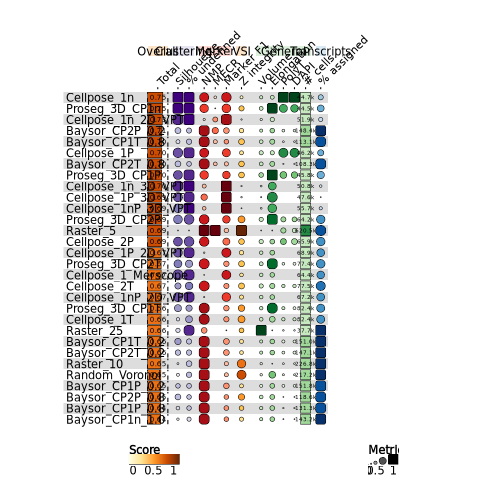

In [18]:
%%R
g